In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

cluster_means_16 = np.load("Jan16_cluster_means.npy")
cluster_means_20 = np.load("Jan20_cluster_means.npy")
cluster_means_22 = np.load("Jan22_cluster_means.npy")

cluster_counts_16 = np.load("Jan16_cluster_counts.npy")
cluster_counts_20 = np.load("Jan20_cluster_counts.npy")
cluster_counts_22 = np.load("Jan22_cluster_counts.npy")

freqs_band = np.load("freqs_band.npy")

k = cluster_means_16.shape[0]   # assume all three use same k


In [2]:
print(cluster_means_16.shape, cluster_means_20.shape, cluster_means_22.shape)


(5, 75) (5, 75) (5, 75)


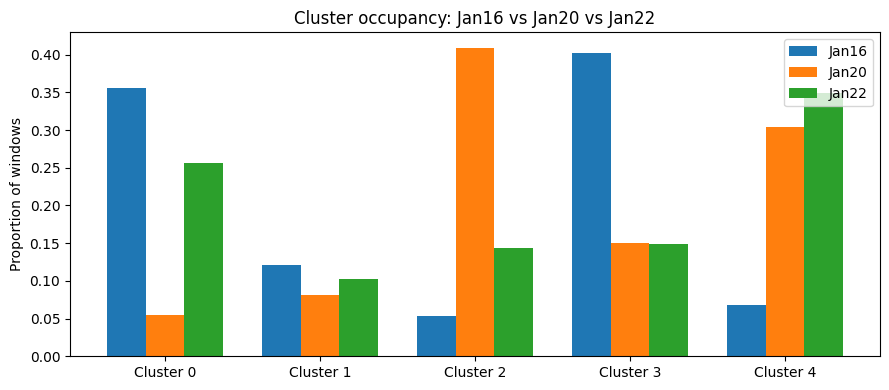

In [3]:
props_16 = cluster_counts_16 / cluster_counts_16.sum()
props_20 = cluster_counts_20 / cluster_counts_20.sum()
props_22 = cluster_counts_22 / cluster_counts_22.sum()

x = np.arange(k)
width = 0.25

plt.figure(figsize=(9,4))
plt.bar(x - width,     props_16, width, label="Jan16")
plt.bar(x,             props_20, width, label="Jan20")
plt.bar(x + width,     props_22, width, label="Jan22")

plt.xticks(x, [f"Cluster {i}" for i in range(k)])
plt.ylabel("Proportion of windows")
plt.title("Cluster occupancy: Jan16 vs Jan20 vs Jan22")
plt.legend()
plt.tight_layout()
plt.show()


In [3]:
sim = cosine_similarity(cluster_means_16, cluster_means_20)
print(sim.shape)  # (k, k)


(5, 5)


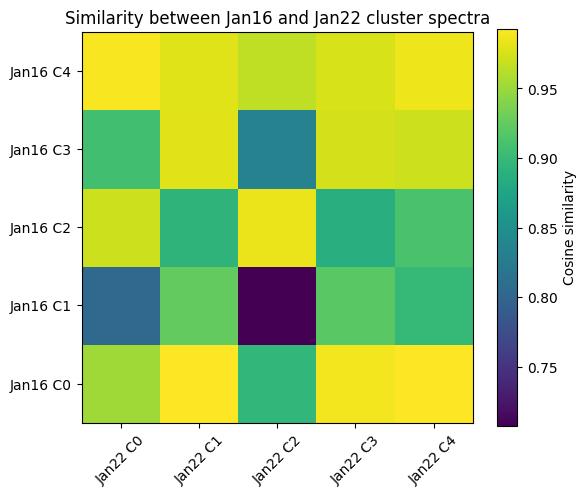

In [4]:
#Comparison Jan 16 Vs Jan 22

sim_16_22 = cosine_similarity(cluster_means_16, cluster_means_22)

plt.figure(figsize=(6,5))
plt.imshow(sim_16_22, origin="lower", cmap="viridis")
plt.colorbar(label="Cosine similarity")

plt.xticks(range(k), [f"Jan22 C{i}" for i in range(k)], rotation=45)
plt.yticks(range(k), [f"Jan16 C{i}" for i in range(k)])
plt.title("Similarity between Jan16 and Jan22 cluster spectra")
plt.tight_layout()
plt.show()



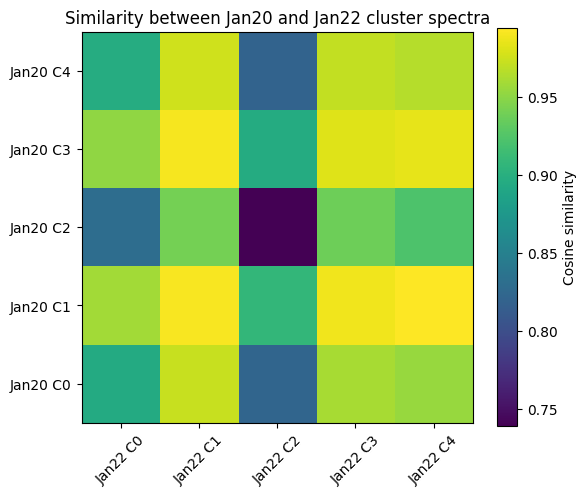

In [5]:
#Comparison Jan 20 vs Jan 22

sim_20_22 = cosine_similarity(cluster_means_20, cluster_means_22)

plt.figure(figsize=(6,5))
plt.imshow(sim_20_22, origin="lower", cmap="viridis")
plt.colorbar(label="Cosine similarity")

plt.xticks(range(k), [f"Jan22 C{i}" for i in range(k)], rotation=45)
plt.yticks(range(k), [f"Jan20 C{i}" for i in range(k)])
plt.title("Similarity between Jan20 and Jan22 cluster spectra")
plt.tight_layout()
plt.show()
